# PRACTICE 2: PREDICTING PRODUCT SALES
## Workflow of Machine Learning Pipeline

### 1. Define Problem 
- Một tập đoàn bán lẻ quản lý chuỗi cửa hàng phân phối tại 10 trung tâm thương mại sầm uất nhất Istanbul (Thổ Nhĩ Kỳ) đang cần giải quyết bài toán quản lý luân chuyển hàng hóa và dòng tiền. Họ muốn dự đoán Doanh thu của từng giao dịch dựa trên thông tin nhân khẩu học của khách hàng và bối cảnh mua sắm.Việc dự đoán được mức chi tiêu này sẽ giúp phía doanh nghiệp đạt được 2 mục tiêu chiến lược:
    - **Tối ưu hóa hàng tồn kho:** Phân bổ chính xác số lượng và loại hàng hóa (Ví dụ: Công nghệ, Quần áo, Thực phẩm) cho từng trung tâm thương mại tại từng thời điểm cụ thể, nhằm giảm chi phí lưu kho và tránh tình trạng "cháy hàng"
    - **Chiến lược Marketing:** Thiết kế các chương trình khuyến mãi cá nhân hóa nhắm đúng vào tệp khách hàng tiềm năng (dựa trên độ tuổi, giới tính, phương thức thanh toán) để tối đa hóa lợi nhuận

### 2. Collect Data
- Bộ dữ liệu bao gồm 99,457 mẫu giao dịch (hóa đơn) với 10 cột thông tin chi tiết. Cấu trúc dữ liệu được chia làm 2 phần:
    - Các biến đặc trưng (Feaures - X):
        - **invoice_no:** Mã hóa đơn (Chuỗi định danh duy nhất cho mỗi giao dịch)
        - **customer_id:** Mã định danh khách hàng
        - **gender:** Giới tính của khách hàng (Male / Female)
        - **age:** Độ tuổi của khách hàng
        - **category:** Ngành hàng của sản phẩm được mua (Gồm 8 danh mục như Clothing, Cosmetics, Food & Beverage, Technology, Shoes, v.v.)
        - **quantity:** Số lượng sản phẩm được mua trong đơn hàng
        - **payment_method:** Phương thức thanh toán (Cash - Tiền mặt, Credit Card - Thẻ tín dụng, Debit Card - Thẻ ghi nợ)
        - **invoice_date:** Ngày thực hiện giao dịch mua sắm
        - **shopping_mall:** Tên chi nhánh trung tâm thương mại diễn ra giao dịch (Gồm 10 trung tâm lớn tại Istanbul như Kanyon, Mall of Istanbul, Metrocity...)
    - Biến mực tiêu (Target Variable - y):
        - **price:** Giá trị của đơn hàng (Đại diện cho Doanh thu/Revenue mang lại từ giao dịch đó). Đây là biến số liên tục (Continuous Variable) mà các mô hình học máy cần phải học quy luật và dự đoán

In [42]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt

In [43]:
sns.set_theme(style="whitegrid")
data = pd.read_csv('./data/raw-data/customer_shopping_data.csv')

#### Data Overview
- Check số lượng sample
- Check số lượng feature
- Check data type
- Thống kê cơ bản (Mean, Min, Max...) cho các biến số
- Query thử vài dòng sample

In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


- Tập dữ liệu có kích thước khá lớn với 99,457 samples và 10 features
- Cột Non-Null Count đều hiển thị 99457 ở tất cả các feature. Điều này cho thấy bề mặt dữ liệu khá sạch, không có giá trị khuyết thiếu (Null/NaN) rõ ràng nào
- Tuy nhiên feature invoice_date (Ngày mua hàng) hiện đang mang kiểu dữ liệu là str (chuỗi văn bản/object)

-> Bắt buộc phải ép kiểu cột này về định dạng Datetime (Thời gian) thì mới có thể trích xuất được các Feature như Ngày, Tháng, Năm, Cuối tuần ở giai đoạn sau

In [4]:
display(data.describe().round(2))

,age,quantity,price
count,99457.00,99457.00,99457.00
mean,43.43,3.00,689.26
std,14.99,1.41,941.18
min,18.00,1.00,5.23
25%,30.00,2.00,45.45
50%,43.00,3.00,203.30
75%,56.00,4.00,1200.32
max,69.00,5.00,5250.00


- Số lượng mua hàng biến thiên từ 1 đến 5 sản phẩm/đơn hàng, trung bình là 3. Dữ liệu rất sạch, không có số âm vô lý
- Độ tuổi khách hàng dao động từ 18 đến 69 tuổi, độ tuổi trung bình là 43. Không có tuổi bị nhiễu
- Doanh thu hóa đơn đang có dấu hiệu bị méo mó vì trung bình một đơn hàng trị giá $689.26 Lira, nhưng mức trung vị lại chỉ có $203.30. Sự chênh lệch khổng lồ giữa Mean và Median, cộng với mức Max lên tới $5250.00, cho thấy khả năng phân phối của Doanh thu bị lệch phải và chứa rất nhiều Outliers (Khách sộp mua đồ đắt tiền)

-> Bắt buộc phải thực hiện Log-Transform và dùng phương pháp IQR để cắt bỏ Outliers

In [5]:
display(data.describe(include=['object', 'category']))

,invoice_no,customer_id,gender,category,payment_method,invoice_date,shopping_mall
count,99457,99457,99457,99457,99457,99457,99457
unique,99457,99457,2,8,3,797,10
top,I138884,C241288,Female,Clothing,Cash,24/11/2021,Mall of Istanbul
freq,1,1,59482,34487,44447,159,19943


- Tại cột invoice_no và customer_id cho thấy có đúng 99,457 giá trị duy nhất (Unique = 99457). Tức là mỗi dòng là 1 khách hàng mới, không có ai mua lặp lại 2 lần. Hai biến này mang tính chất ID định danh, không có giá trị học máy
- Chân dung tệp khách hàng
    - Giới tính Nữ chiếm ưu thế áp đảo (Top = Female với 59,482 hóa đơn ~ 60%)
    - Ngành hàng bán chạy nhất là Quần áo (Clothing) với 34,487 đơn (Chiếm ~35%)
    - Ngành hàng bán chạy nhất là Quần áo (Clothing) với 34,487 đơn (Chiếm ~35%)
    - Địa điểm đông khách nhất là Mall of Istanbul (19,943 đơn)
-> Drop 2 cột invoice_no và customer_id tại bước Data Cleaning

In [6]:
data.head(5)

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


Dựa vào kết quả lấy 5 sample đầu tiên của raw dataset, ta cũng nhận ra điểm bất thường là
- Tại hóa đơn I127801, mua mặt hàng Clothing với số lượng một có price là 300.08 Lira
- Tại hóa đơn I138884, mua mặt hàng Clothing với số lượng 5 có price là 1500.40 Lira (Tương đương 300.08 * 5)

Vậy Giá trị ở cột `price` tăng tỷ lệ thuận tuyệt đối với cột `quantity`. Điều này là minh chứng cho thấy cột `price` trong Raw Data thực chất đã là **Tổng giá trị hóa đơn (Total Revenue)**, hoàn toàn không phải Đơn giá bán lẻ (Unit Price) như mô tả gốc của tác giả trên Kaggle

#### Missing Data Analysis
- Tính tỷ lệ missing theo từng feature một
- Visualize Seaborn Heatmap nhỏ gọn để minh họa sự vắng mặt của dữ liệu

In [7]:
# Tính toán số lượng và tỷ lệ % missing
missing_data = data.isnull().sum()
missing_percent = (missing_data / len(data)) * 100

missing_table = pd.DataFrame({
    'Số lượng Missing': missing_data, 
    'Tỷ lệ (%)': missing_percent
})

In [8]:
display(missing_table.sort_values(by='Tỷ lệ (%)', ascending=False))

,Số lượng Missing,Tỷ lệ (%)
invoice_no,0,0.0
customer_id,0,0.0
gender,0,0.0
age,0,0.0
category,0,0.0
quantity,0,0.0
price,0,0.0
payment_method,0,0.0
invoice_date,0,0.0
shopping_mall,0,0.0


C:\Users\minhchi\AppData\Local\Temp\ipykernel_4980\3707565947.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=missing_percent.values, y=missing_percent.index, palette='viridis')


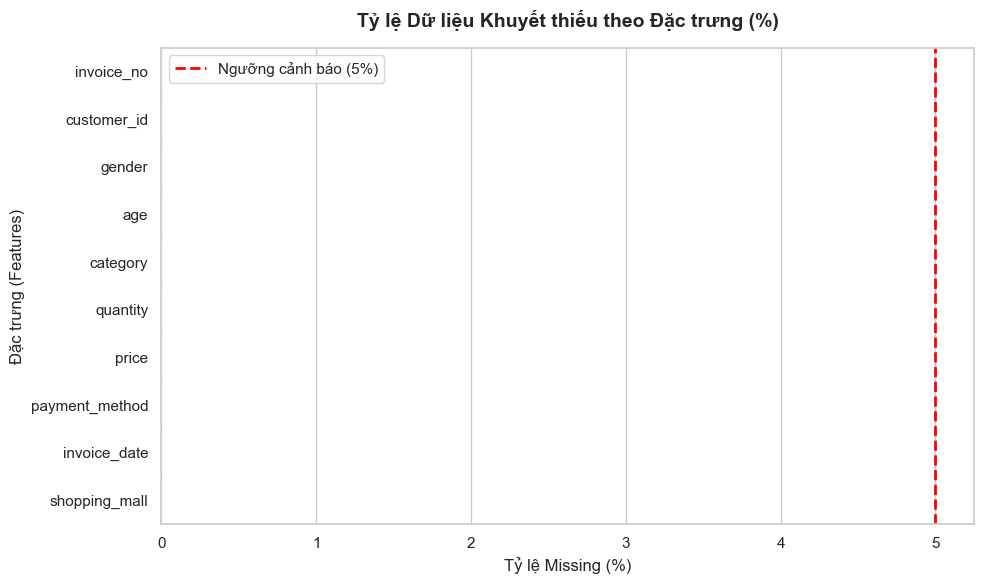

In [9]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(x=missing_percent.values, y=missing_percent.index, palette='viridis')

plt.title('Tỷ lệ Dữ liệu Khuyết thiếu theo Đặc trưng (%)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tỷ lệ Missing (%)', fontsize=12)
plt.ylabel('Đặc trưng (Features)', fontsize=12)

plt.axvline(x=5, color='red', linestyle='--', linewidth=2, label='Ngưỡng cảnh báo (5%)')
plt.legend()

plt.tight_layout()
plt.show()

#### Univariate Analysis
- Nhóm Numerical (Tuổi, Số lượng, Giá trị đơn hàng - Đại diện cho Doanh thu): Visualize distribution plot để đánh giá độ lệch
- Nhóm Categorical (Giới tính, Ngành hàng, Thanh toán): Visualize đồ thị tần suất để kiểm tra độ cân bằng class
- Nhóm Time Series: Trích xuất ra thành phần Tháng và Ngày trong tuần để visualize đồ thị tần suất đánh giá lưu lượng khách hàng tập trung vào thời điểm nào trong năm/tuần


🔸 Biến: AGE
   - Độ lệch (Skewness): 0.0090
   - Giá trị từng cột (Bin) trên biểu đồ:
     + Cột 1 [Từ   18.00 đến   23.10]:  11519 hóa đơn
     + Cột 2 [Từ   23.10 đến   28.20]:   9639 hóa đơn
     + Cột 3 [Từ   28.20 đến   33.30]:   9536 hóa đơn
     + Cột 4 [Từ   33.30 đến   38.40]:   9689 hóa đơn
     + Cột 5 [Từ   38.40 đến   43.50]:   9691 hóa đơn
     + Cột 6 [Từ   43.50 đến   48.60]:   9526 hóa đơn
     + Cột 7 [Từ   48.60 đến   53.70]:   9597 hóa đơn
     + Cột 8 [Từ   53.70 đến   58.80]:   9343 hóa đơn
     + Cột 9 [Từ   58.80 đến   63.90]:   9488 hóa đơn
     + Cột 10 [Từ   63.90 đến   69.00]:  11429 hóa đơn

🔸 Biến: QUANTITY
   - Độ lệch (Skewness): -0.0013
   - Giá trị từng cột (Bin) trên biểu đồ:
     + Cột 1 [Từ    1.00 đến    1.40]:  19767 hóa đơn
     + Cột 2 [Từ    1.40 đến    1.80]:      0 hóa đơn
     + Cột 3 [Từ    1.80 đến    2.20]:  19828 hóa đơn
     + Cột 4 [Từ    2.20 đến    2.60]:      0 hóa đơn
     + Cột 5 [Từ    2.60 đến    3.00]:      0 hóa đơn
     + Cộ

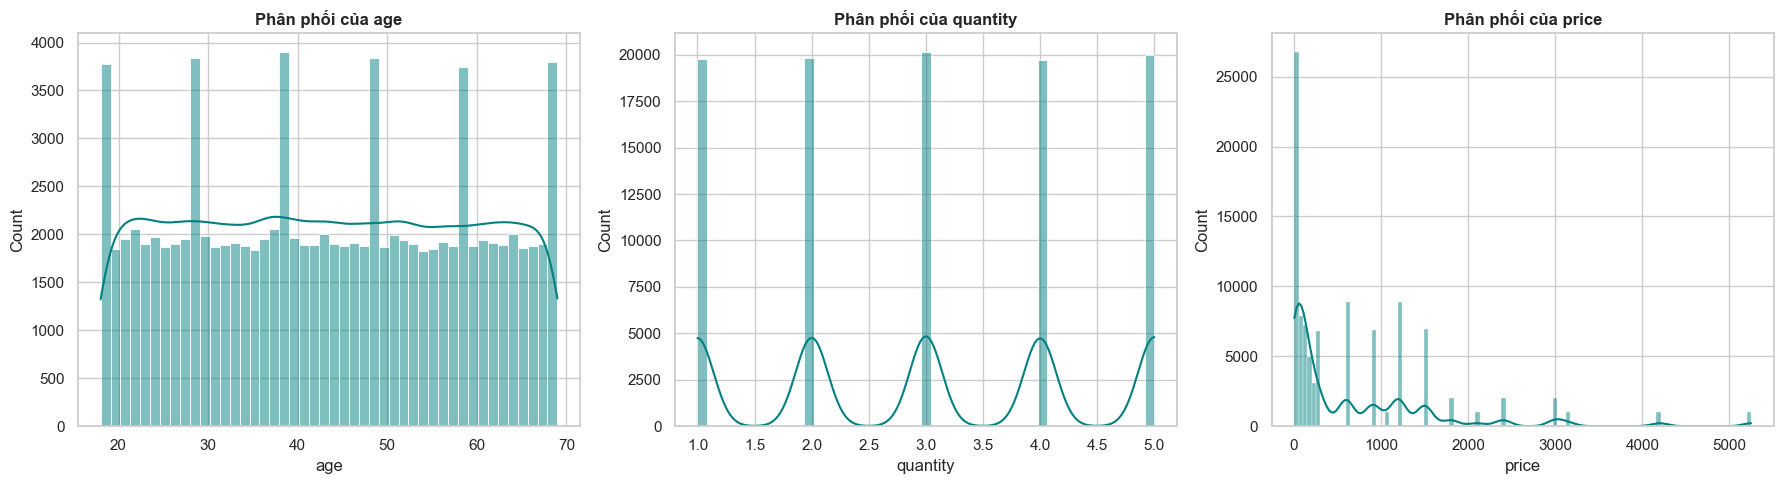

In [ ]:
# Nhóm Numerical (Tuổi , Số lượng, Doanh Thu)
num_cols = ['age', 'quantity', 'price']
for col in num_cols:
    print(f"\n🔸 Biến: {col.upper()}")
    # Tính độ lệch
    print(f"   - Độ lệch (Skewness): {data[col].skew():.4f}")
    
    # Chia thành 10 cột (bins) giống như vẽ histplot và đếm số lượng mẫu trong mỗi cột
    counts, bin_edges = np.histogram(data[col].dropna(), bins=10)
    
    print("   - Giá trị từng cột (Bin) trên biểu đồ:")
    for i in range(len(counts)):
        print(f"     + Cột {i+1} [Từ {bin_edges[i]:>7.2f} đến {bin_edges[i+1]:>7.2f}]: {counts[i]:>6} hóa đơn")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.histplot(data[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Phân phối của {col}', fontsize=12, fontweight='bold')
    
plt.tight_layout()
plt.show()

Dựa vào kết quả visualize phân bố trên:
- Tuổi tác khách hàng phân bố đồng đều
    - Độ lệch (Skewness) = 0.0090: Con số này tiệm cận 0, chứng tỏ tuổi tác của khách hàng có phân phối gần như đối xứng hoàn hảo, không bị lệch về nhóm người già hay người trẻ
    - Lượng khách hàng dàn trải cực kỳ đều ở mọi độ tuổi (khoảng 9,500 hóa đơn cho mỗi dải 5 tuổi). Đặc biệt, tập khách hàng hơi nhỉnh hơn một chút ở hai đầu mút: nhóm trẻ (18-23 tuổi) với 11,519 hóa đơn và nhóm lớn tuổi (64-69 tuổi) với 11,429 hóa đơn

-> Các trung tâm thương mại trong tập dữ liệu phục vụ tốt cho mọi lứa tuổi. Không có sự thống trị của bất kỳ thế hệ nào (Gen Z, Millennials hay Boomers đều mua sắm ngang nhau)

- Số lượng sản phẩm phân bố cân bằng tuyệt đối
    - Độ lệch (Skewness) = -0.0013: Hoàn toàn không bị lệch
    - Việc xuất hiện các mốc "0 hóa đơn" xen kẽ chứng minh rằng quantity là một biến số nguyên rời rạc. Khách hàng chỉ mua đúng 1, 2, 3, 4, hoặc 5 sản phẩm. Đặc biệt, số lượng hóa đơn cho mỗi mức mua (từ 1 đến 5) là bằng nhau chằn chặn (dao động sát mốc 20,000 hóa đơn mỗi loại)

-> Có thể giới hạn của giỏ hàng là 5 sản phẩm/đơn. Sự phân bổ đều tăm tắp này cho thấy không có xu hướng khách hàng thích mua lẻ 1 món hay mua sỉ 5 món

- Tại Giá trị hóa đơn(Price - Đại diện cho Tổng doanh thu):
    - Độ lệch (Skewness) = 2.2474: Độ lệch dương rất lớn (> 1), đây là bằng chứng cho thấy cột price (tổng doanh thu hóa đơn) bị lệch phải cực kỳ nặng nề
    - Hơn 57% tổng số hóa đơn (56,781 / 99,457) tập trung ở phân khúc bình dân (giá trị rất thấp, từ 5.23 đến 529.71 Lira)
        - Càng tiến về mức giá cao, số lượng hóa đơn càng rớt thảm hại. Tuy nhiên, tập dữ liệu vẫn xuất hiện những nhóm "Outlier" (Khách sộp) mua các đơn hàng xa xỉ tạo thành một cái đuôi dài: có 1001 đơn hàng trên 4200 Lira và 1001 đơn hàng chạm mức đỉnh 5250 Lira
        
-> Phân phối này phản ánh chuẩn xác thực tế ngành bán lẻ: Đa số khách hàng chỉ mua các món đồ lặt vặt, giá trị thấp. Tuy nhiên, doanh nghiệp vẫn sống khỏe nhờ một tệp "Khách hàng VIP" nhỏ giọt nhưng chịu chi hàng ngàn Lira cho các mặt hàng xa xỉ (như Đồ công nghệ, Giày dép cao cấp). Vì phân bố lệch phải quá mạnh, nếu đưa nguyên gốc feature price vào mô hình Linear Regression, mô hình sẽ bị bias hoàn toàn. Nhóm bắt buộc phải thực hiện Log-Transform ở khâu Feature Engineering lên biến mục tiêu price (Tổng doanh thu) để kéo phân phối này về dạng hình chuông, giúp mô hình dự đoán chính xác cả khách bình dân lẫn khách VIP

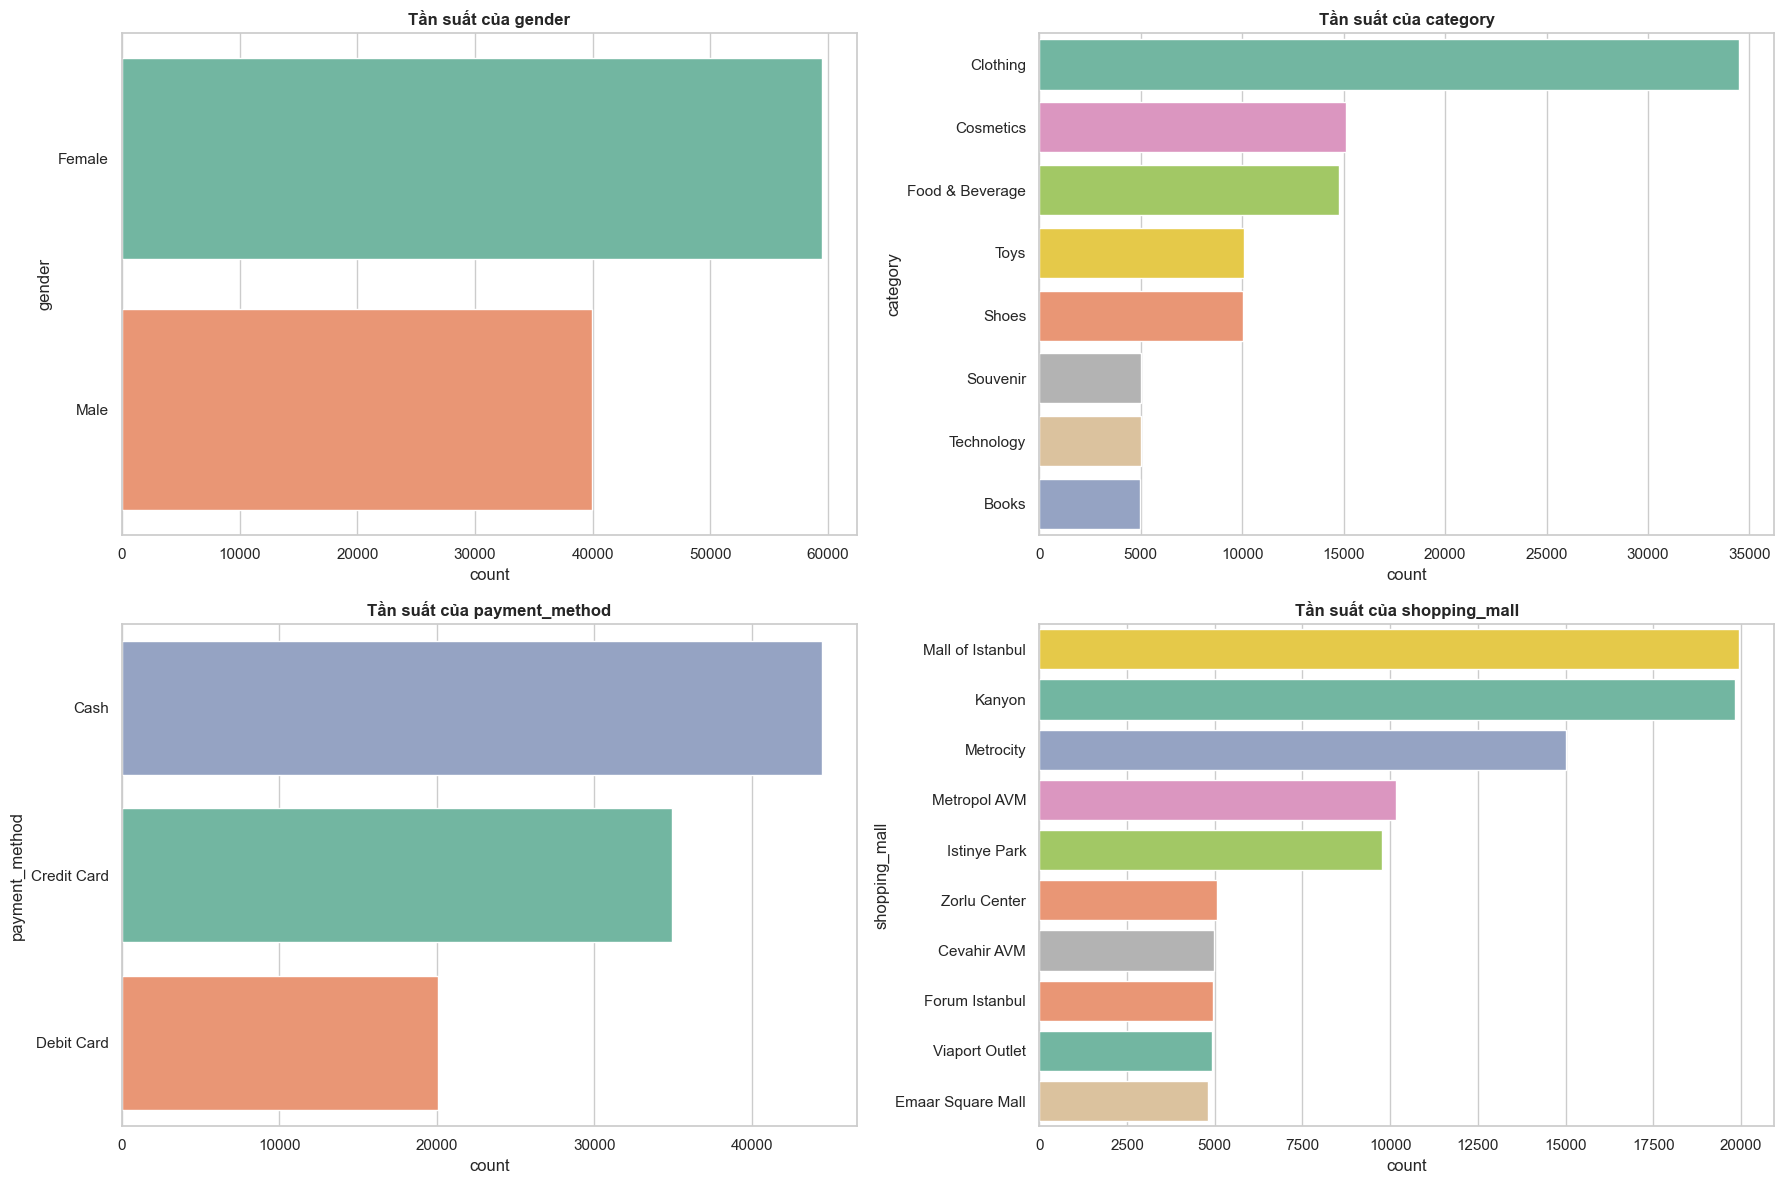

In [ ]:
# Nhóm Categorical (Giới tính, Ngành hàng, Thanh toán, Mall)
cat_cols = ['gender', 'category', 'payment_method', 'shopping_mall']
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(
    y=data[col], 
    hue=data[col],          # Chỉ định biến để phân màu
    ax=axes[i], 
    palette='Set2', 
    legend=False,         
    order=data[col].value_counts().index
)
    axes[i].set_title(f'Tần suất của {col}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Dựa vào kết quả tần suất trên nhóm Categorical, ta có:
- Giới tính khách hàng:
    - Tập dữ liệu có sự chênh lệch (Imbalance) nhẹ giữa hai giới tính. Khách hàng Nữ (Female) chiếm ưu thế với gần 60.000 đơn hàng (~60%), trong khi Nam (Male) chỉ có khoảng 40.000 đơn hàng (~40%)

-> Phụ nữ là tệp khách hàng cốt lõi và là người đưa ra quyết định mua sắm chính tại các trung tâm thương mại này. Các chiến dịch Marketing nên ưu tiên thiết kế hình ảnh và thông điệp hướng tới phái Đẹp để tối ưu tỷ lệ chuyển đổi (Conversion Rate). Vì tỷ lệ 60:40 là một tỷ lệ mất cân bằng ở mức độ chấp nhận được nên không cần phải sử dụng các kỹ thuật cân bằng dữ liệu (như SMOTE hay Undersampling) vì nó vẫn phản ánh đúng tỷ lệ tự nhiên của tệp khách hàng mua lẻ

- Ngành hàng:
    - Dữ liệu chia thành 3 phân lớp rõ rệt:
        - Dẫn đầu: Clothing thống trị tuyệt đối với gần 35.000 đơn hàng (chiếm hơn 1/3 tổng lượng giao dịch)
        - Tầm trung: Mỹ phẩm (Cosmetics) và Đồ ăn thức uống (Food & Beverage) bám đuổi với 15.000 đơn mỗi loại; tiếp theo là Đồ chơi (Toys) và Giày dép (Shoes) với 10.000 đơn
        - Đặc thù/Niche: Đồ lưu niệm (Souvenir), Đồ công nghệ (Technology) và Sách (Books) nằm ở đáy bảng xếp hạng, chỉ đóng góp 5.000 đơn mỗi loại

-> Nhu cầu mua sắm tại Mall chủ yếu tập trung vào các mặt hàng may mặc và tiêu dùng nhanh. Các mặt hàng giá trị cao (Công nghệ) hoặc mua một lần (Sách, Đồ lưu niệm) có tần suất giao dịch rất thấp

- Phương thức thanh toán:
    - Tiền mặt (Cash) là phương thức thanh toán phổ biến nhất với hơn 40.000 giao dịch. Theo sau là Thẻ tín dụng (Credit Card) với khoảng 35.000 giao dịch. Thẻ ghi nợ (Debit Card) ít được sử dụng nhất (đúng 20.000 giao dịch)

-> Mặc dù công nghệ tài chính phát triển, nhưng một bộ phận rất lớn khách hàng vẫn giữ thói quen dùng tiền mặt. (Giả thuyết: Có thể đa số các đơn hàng tiền mặt thuộc về phân khúc giá rẻ như Đồ ăn/Nước uống. Chúng ta sẽ kiểm chứng giả thuyết này ở bước phân tích đa biến)

- Trung tâm thương mại:
    - Trong số 10 trung tâm thương mại, có sự phân bổ lưu lượng không đồng đều:
        - Top 3 "Ông lớn": Mall of Istanbul (~20.000 đơn), Kanyon (<20.000 đơn) và Metrocity (15.000 đơn) chiếm phần lớn "miếng bánh" thị phần
        - Nhóm bám đuổi: Metropol AVM và Istinye Park (quanh mốc 10.000 đơn)
        - Nhóm thấp nhất: Các Mall còn lại như Zorlu Center, Cevahir AVM, Forum Istanbul, Viaport Outlet đều nằm ở mốc 5.000 đơn, riêng Emaar Square Mall chạm đáy với lượng đơn thấp nhất (<5.000)

-> Vị trí địa lý và quy mô của Mall quyết định trực tiếp đến lưu lượng khách. Việc phân phối hàng hóa tồn kho phải được rót trọng tâm vào Top 3 Mall dẫn đầu để tránh đọng vốn tại các Mall vắng khách

In [11]:
df_time = data.copy()
df_time['invoice_date'] = pd.to_datetime(df_time['invoice_date'], format='%d/%m/%Y')
df_time['Month'] = df_time['invoice_date'].dt.month
df_time['DayOfWeek'] = df_time['invoice_date'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_time['DayOfWeek'] = pd.Categorical(df_time['DayOfWeek'], categories=days_order, ordered=True)

In [15]:
print((df_time['Month'].value_counts(normalize=True) * 100).round(2).sort_index().to_string())

Month
1     11.67
2     10.54
3      8.78
4      7.53
5      7.74
6      7.62
7      7.92
8      7.68
9      7.39
10     7.81
11     7.60
12     7.72


In [16]:
print((df_time['DayOfWeek'].value_counts(normalize=True) * 100).round(2).sort_index().to_string())

DayOfWeek
Monday       14.46
Tuesday      14.29
Wednesday    14.20
Thursday     14.21
Friday       14.43
Saturday     14.20
Sunday       14.22


C:\Users\minhchi\AppData\Local\Temp\ipykernel_4980\3319817505.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_time, x='Month', ax=axes[0], palette='viridis')
C:\Users\minhchi\AppData\Local\Temp\ipykernel_4980\3319817505.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_time, x='DayOfWeek', ax=axes[1], palette='magma')


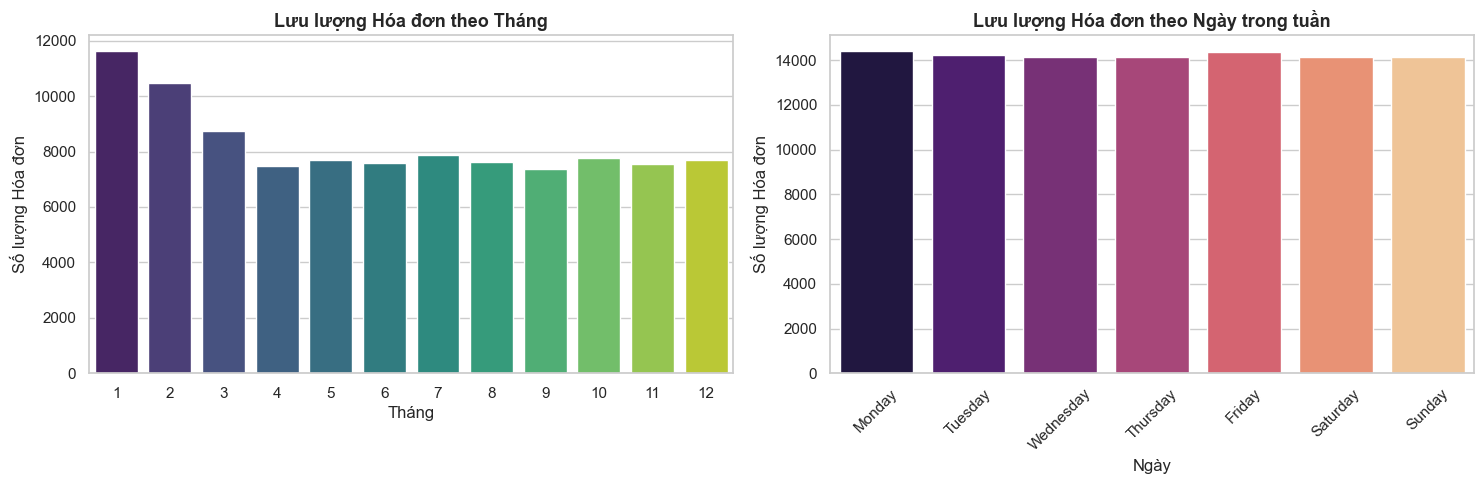

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ Lưu lượng theo Tháng
sns.countplot(data=df_time, x='Month', ax=axes[0], palette='viridis')
axes[0].set_title('Lưu lượng Hóa đơn theo Tháng', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tháng')
axes[0].set_ylabel('Số lượng Hóa đơn')

# Biểu đồ Lưu lượng theo Ngày trong tuần
sns.countplot(data=df_time, x='DayOfWeek', ax=axes[1], palette='magma')
axes[1].set_title('Lưu lượng Hóa đơn theo Ngày trong tuần', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Ngày')
axes[1].set_ylabel('Số lượng Hóa đơn')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Dựa vào kết quả visualize lưu lượng theo thời gian, ta phát hiện ra những quy luật kinh doanh:
- Lưu lượng theo Ngày trong tuần (Day of Week):
    - Tỷ lệ đơn hàng phân bổ đều tăm tắp cho cả 7 ngày trong tuần (dao động cực nhỏ từ 14.20% đến 14.46%). Không hề có bất kỳ sự chênh lệch nào giữa ngày thường (Weekday) và Cuối tuần (Weekend)

-> Các trung tâm thương mại tại Istanbul trong tập dữ liệu này duy trì được lượng traffic (lưu lượng khách) cực kỳ ổn định mỗi ngày. Hoàn toàn không tồn tại "Hiệu ứng cuối tuần" như các mô hình bán lẻ truyền thống. (Lưu ý: Sự đồng đều tuyệt đối này một lần nữa khẳng định tập dữ liệu đã được Uniform Sampling)

- Lưu lượng theo Tháng (Month):
    - Trái ngược với suy nghĩ thông thường rằng Tháng 12 (Giáng sinh) là mùa mua sắm cao điểm, dữ liệu cho thấy lượng hóa đơn Tháng 12 chỉ ở mức trung bình (7.72%). Thay vào đó, sức mua bùng nổ mạnh mẽ vào Tháng 1 (11.67%) và Tháng 2 (10.54%), sau đó rớt xuống và đi ngang ở mốc ~7.5% cho 10 tháng còn lại trong năm

-> Sự gia tăng đột biến của lượng đơn hàng trong 2 tháng đầu năm chính là dấu hiệu rõ ràng nhất của tính Thời vụ. Rất có thể các thương hiệu trong Mall đồng loạt tung ra chiến dịch "Winter Clearance Sale" (Xả hàng mùa đông) hoặc "New Year Promo" (Khuyến mãi Năm mới) vào giai đoạn này

Từ các phân tích trên, để mô hình còn có thể phân tích được tác động của chiến dịch Marketing, nhóm sẽ tạo mới một feature mới là Is_Promotion_Campaign. Tuy nhiên, thay vì gán cho Cuối tuần hay Tháng 12, biến này sẽ được kích hoạt (bằng 1) vào Tháng 1 và Tháng 2, và bằng 0 cho các tháng còn lại. Đây sẽ là biến cờ giúp mô hình Học máy bắt được xu hướng kích cầu đầu năm của doanh nghiệp

#### **Bivariate/Multivariate Analysis**
- Numerical vs Numerical:
    - Sử dụng Ma trận tương quan giữa các biến số gồm age, quantity, price để kiểm tra hiện tượng đa cộng tuyến (Ví dụ: age và quantity có tương quan với nhau không ?, ...)
    - Sử dụng Scatter Plots để xem xét xu hướng tuyến tính giữa các cặp biến số
        - age vs price
        - age vs quantity
- Categorical vs Numerical:
    - Sử dụng Boxplot và Barplot để trả lời các câu hỏi về doanh thu
        - Ngành hàng nào mang lại giá trị hóa đơn (price) trung vị cao nhất?
        - Trung tâm thương mại nào có phổ doanh thu rộng nhất hoặc có nhiều hóa đơn giá trị cao (outliers) nhất?
        - Giá trị hóa đơn trung bình theo giới tính
        - Giá trị hóa đơn trung bình theo phương thức thanh toán
- Categorical vs Categorical:
    - Sử dụng Bảng chéo tần suất (Contingency tables / pd.crosstab), kết hợp vẽ Biểu đồ cột nhóm (Grouped Bar Charts) hoặc Biểu đồ cột chồng (Stacked Bar Charts). Nếu cần tính nghiêm ngặt về mặt thống kê, có thể áp dụng kiểm định Chi-square (Chi-square tests)
        - Insight nhân khẩu học: Phân bổ giới tính (gender) tại các shopping_mall khác nhau như thế nào? (Mall nào hút khách nam hơn, mall nào hút khách nữ hơn?)
        - Insight hành vi mua sắm: Sở thích chọn ngành hàng (category) có sự khác biệt giữa Nam và Nữ không?
        - Insight thanh toán: Khách hàng ưu tiên dùng phương thức thanh toán (payment_method) nào cho từng loại ngành hàng cụ thể?
- Time Series vs Numerical:
    - Sử dụng Barplot/Linechart để xem xét giá trị hóa đơn trung bình thay đổi thế nào theo Tháng (Tháng 12 có tăng vọt không?) và theo Ngày trong tuần (Cuối tuần có chi tiêu cao hơn không?)

In [17]:
# Tạo ma trận tương quan cho các biến số học
num_df = data[['age', 'quantity', 'price']]
corr_matrix = num_df.corr()

In [21]:
display(corr_matrix.round(3))

,age,quantity,price
age,1.000,0.001,0.002
quantity,0.001,1.000,0.345
price,0.002,0.345,1.000


C:\Users\minhchi\AppData\Local\Temp\ipykernel_4980\952132899.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=data, x='quantity', y='age', ax=axes[2], palette='Set2', jitter=True, alpha=0.1)


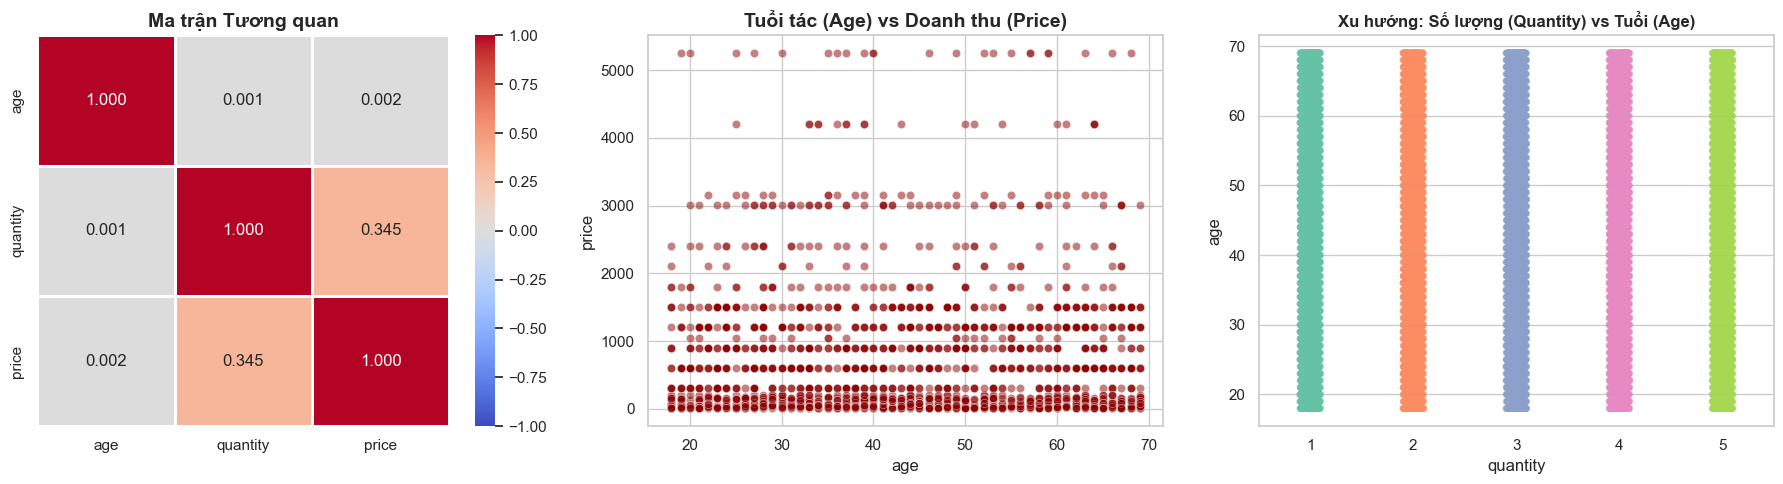

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Heatmap Ma trận tương quan
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", 
            linewidths=1, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Ma trận Tương quan', fontsize=14, fontweight='bold')


# Scatter plot (Mối quan hệ giữa Tuổi và Doanh thu)
# Random 2000 sample để vẽ Scatter plot cho nhẹ
sample_df = data.sample(2000, random_state=42)
sns.scatterplot(data=sample_df, x='age', y='price', alpha=0.5, color='darkred', ax=axes[1])
axes[1].set_title('Tuổi tác (Age) vs Doanh thu (Price)', fontsize=14, fontweight='bold')

# Biểu đồ phân tán giữa Tuổi và Số lượng
# Vì quantity là số rời rạc (1, 2, 3, 4, 5), dùng stripplot với jitter sẽ giúp các điểm không bị đè nát lên nhau
sns.stripplot(data=data, x='quantity', y='age', ax=axes[2], palette='Set2', jitter=True, alpha=0.1)
axes[2].set_title('Xu hướng: Số lượng (Quantity) vs Tuổi (Age)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Dựa vào kết quả trên, cho thấy:
-  Tuổi tác hoàn toàn vô can đến Doanh thu (Correlation $\approx$ 0)
    - Hệ số tương quan giữa age và price (Doanh thu) là 0.002 (gần như bằng 0 tuyệt đối). Tương tự, age cũng không có quan hệ tuyến tính nào với quantity (0.001)

-> Tuổi tác không phải là nhân tố quyết định việc "chốt đơn" lớn hay nhỏ. Các chiến dịch Upsell (bán chéo, bán thêm) không nên chỉ tập trung vào nhóm khách hàng lớn tuổi (những người thường được mặc định là có tài chính tốt hơn), vì Gen Z trong tệp dữ liệu này cũng chịu chi không kém

Vì feature age có quan hệ tuyến tính cực yếu với $y$, thuật toán Linear/Ridge Regression sẽ đánh trọng số của biến này gần bằng 0. Do đó, thực hiện Rời rạc hóa (Binning) biến age thành các nhóm tuổi (Gen Z, Boomers...) ở khâu Feature Engineering có thể giúp mô hình bắt được các quy luật phi tuyến (nếu có)

- Nhìn vào Scatter plot (Tuổi vs Doanh thu), ta không thấy các chấm bi phân bổ ngẫu nhiên mà chúng xếp thành các đường kẻ ngang song song nhau

-> Điều này cho thấy trong dataset này có mức giá bán được cố định (hoặc biên độ giá rất hẹp) cho từng loại ngành hàng. Khi lấy mức giá cố định này nhân với số lượng mua là các số nguyên rời rạc (1, 2, 3, 4, 5), kết quả doanh thu (price) sinh ra sẽ bị "lượng tử hóa", tạo thành các bậc thang ngang

- Mối quan hệ giữa Số lượng và Doanh thu yếu hơn kỳ vọng (0.345), theo logic thông thường là mua nhiều món thì tốn nhiều tiền. Tuy nhiên, hệ số tương quan giữa quantity và price chỉ dừng lại ở mức trung bình (0.345) chứ không tiệm cận mức hoàn hảo (0.8 hay 0.9)

-> Cho thấy doanh thu của trung tâm thương mại "trọng chất hơn trọng lượng". Tổng bill được kéo lên chủ yếu bởi việc bán các mặt hàng giá trị cao (như Công nghệ, Mỹ phẩm) chứ không phải nhờ việc khách hàng mua số lượng nhiều. (Ví dụ: Khách mua 5 ly trà sữa giá vẫn thấp hơn rất nhiều so với mua 1 đôi giày). Điều này dọn đường hoàn hảo để nhóm chuyển sang phân tích xem Ngành hàng nào mới thực sự mang lại doanh thu ở phần tiếp theo

- Mối quan hệ giữa Sô lượng và Tuổi cho thấy phân bổ đều đặn theo chiều dọc (tại các mức quantity 1, 2, 3, 4, 5) và trải dài đồng nhất trên toàn bộ trục tuổi (từ 18 đến 69). Không có bất kỳ sự tập trung nào của một nhóm tuổi cụ thể vào một mức số lượng sản phẩm nhất định (Ví dụ: Không có chuyện người trẻ thì mua 1 món, còn người lớn tuổi thì mua 5 món)

-> Hành vi mua sắm với số lượng sản phẩm khác nhau không bị ảnh hưởng bởi yếu tố tuổi tác. Dù là khách hàng 18 tuổi hay 69 tuổi, xác suất họ chọn mua 1 món hay 5 món là tương đương nhau

In [23]:
display(data.groupby('category')['price'].agg(['mean', 'median', 'std']).sort_values(by='median', ascending=False))

,mean,median,std
category,,,
Technology,3156.935548,3150.00,1481.559805
Shoes,1807.388568,1800.51,845.116269
Clothing,901.084021,900.24,424.225594
Cosmetics,122.448626,121.98,57.458097
Toys,107.733185,107.52,50.364844
Books,45.568621,45.45,21.492662
Souvenir,34.894345,35.19,16.564498
Food & Beverage,15.671948,15.69,7.422176


C:\Users\minhchi\AppData\Local\Temp\ipykernel_4980\3584806023.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='category', y='price', ax=axes[0],
C:\Users\minhchi\AppData\Local\Temp\ipykernel_4980\3584806023.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='category', y='price', ax=axes[1], palette='magma')


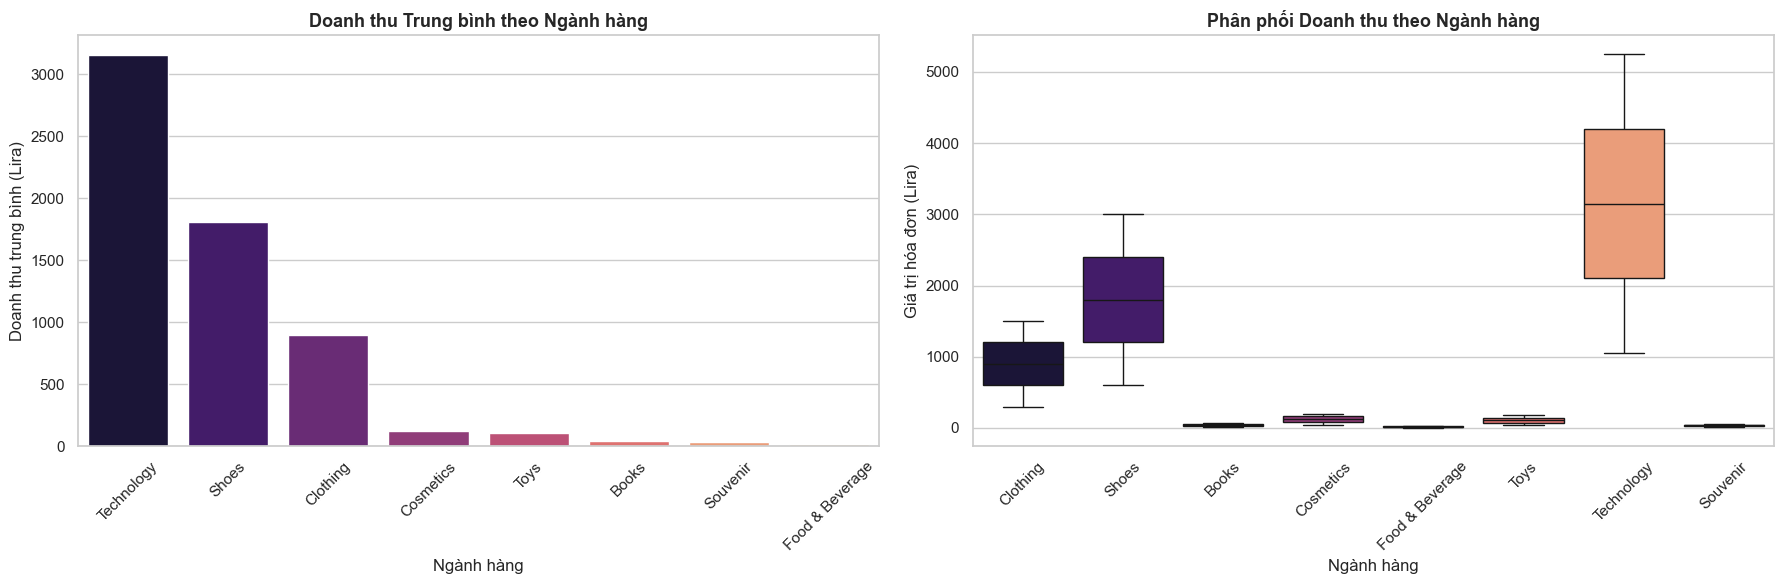

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Doanh thu trung bình theo Ngành hàng
category_order = data.groupby('category')['price'].mean().sort_values(ascending=False).index
sns.barplot(data=data, x='category', y='price', ax=axes[0], 
            palette='magma', order=category_order, errorbar=None)
axes[0].set_title('Doanh thu Trung bình theo Ngành hàng', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Ngành hàng')
axes[0].set_ylabel('Doanh thu trung bình (Lira)')
axes[0].tick_params(axis='x', rotation=45)

# Phân phối doanh thu theo Ngành hàng (Check Outliers & Spread)
sns.boxplot(data=data, x='category', y='price', ax=axes[1], palette='magma')
axes[1].set_title('Phân phối Doanh thu theo Ngành hàng', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Ngành hàng')
axes[1].set_ylabel('Giá trị hóa đơn (Lira)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Dựa vào kết quả thống kê trên, ta có được các phân tích sau:
- Có một sự đối lập so với bước trước đó (Phân tích đơn biến) là trước đó Technology là ngành hàng được ít đơn nhất (nằm ở đáy bảng tần suất) nhưng khi phân tích đa biến thì Technology lại là ngành hàng mang về doanh thu trung bình 11,581 Lira / đơn hàng, cao gấp đôi vị trí số hai là Giày dép (6,632 Lira) và gấp gần 4 lần Quần áo (3,305 Lira). Ngược lại, ngành hàng Food & Beverage dù có lượng đơn hàng khổng lồ (Top 3) nhưng doanh thu mỗi đơn lại lẹt đẹt ở mức thấp nhất (57.49 Lira)

-> Quần áo và Đồ ăn là sản phẩm mồi giúp thu hút lưu lượng khách đến Mall thường xuyên. Còn Đồ Công nghệ và Giày dép mới là mấu chốt mang lại dòng tiền thực sự nên ta có thể đặt các cửa hàng Công nghệ ở gần khu vực Đồ ăn để kích thích nhu cầu mua sắm chéo. Từ đó ta cũng thấy rằng feature category có sức mạnh phân loại doanh thu cực tốt (Phân tầng rõ rệt từ 57 lên 11,581). Chắc chắn sau khi train xong, category sẽ là feature quan trọng cao nhất trong mô hình Random Forest

- Trong phân phối doanh thu theo ngành hàng không hề tồn tại dấu chấm Outlier nào, hơn nữa giá trị Mean và Median của mọi ngành hàng có chênh lệch ở mức 0.1% - 0.3%

-> Điều này lật ngược lại hoàn toàn kết luận ở phần Phân tích Đơn biến trước đó! Cái đuôi dài lệch phải của phân phối Doanh thu không phải do các "tỷ phú/khách VIP" vung tiền mua đồ dị biệt, mà đơn giản là do sự chênh lệch mức giá cơ sở giữa Công nghệ và Đồ ăn quá lớn. Bản thân trong mỗi ngành hàng, giá bán rất đồng nhất và tuân thủ đúng bậc thang số lượng từ 1 đến 5

In [27]:
display(data.groupby('shopping_mall')['price'].agg(['mean', 'median', 'std']).sort_values(by='mean', ascending=False).round(2))

,mean,median,std
shopping_mall,,,
Emaar Square Mall,704.72,300.08,957.86
Viaport Outlet,694.75,300.08,953.75
Mall of Istanbul,694.57,203.30,946.27
Kanyon,691.66,203.30,952.00
Zorlu Center,691.56,203.30,948.45
Cevahir AVM,687.97,203.30,952.00
Istinye Park,686.75,203.30,932.39
Metrocity,682.83,203.30,930.24
Metropol AVM,682.81,203.30,923.46


C:\Users\minhchi\AppData\Local\Temp\ipykernel_4980\4033994471.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='shopping_mall', y='price', ax=axes[0], palette='crest', errorbar=None)
C:\Users\minhchi\AppData\Local\Temp\ipykernel_4980\4033994471.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='shopping_mall', y='price', ax=axes[1], palette='flare')


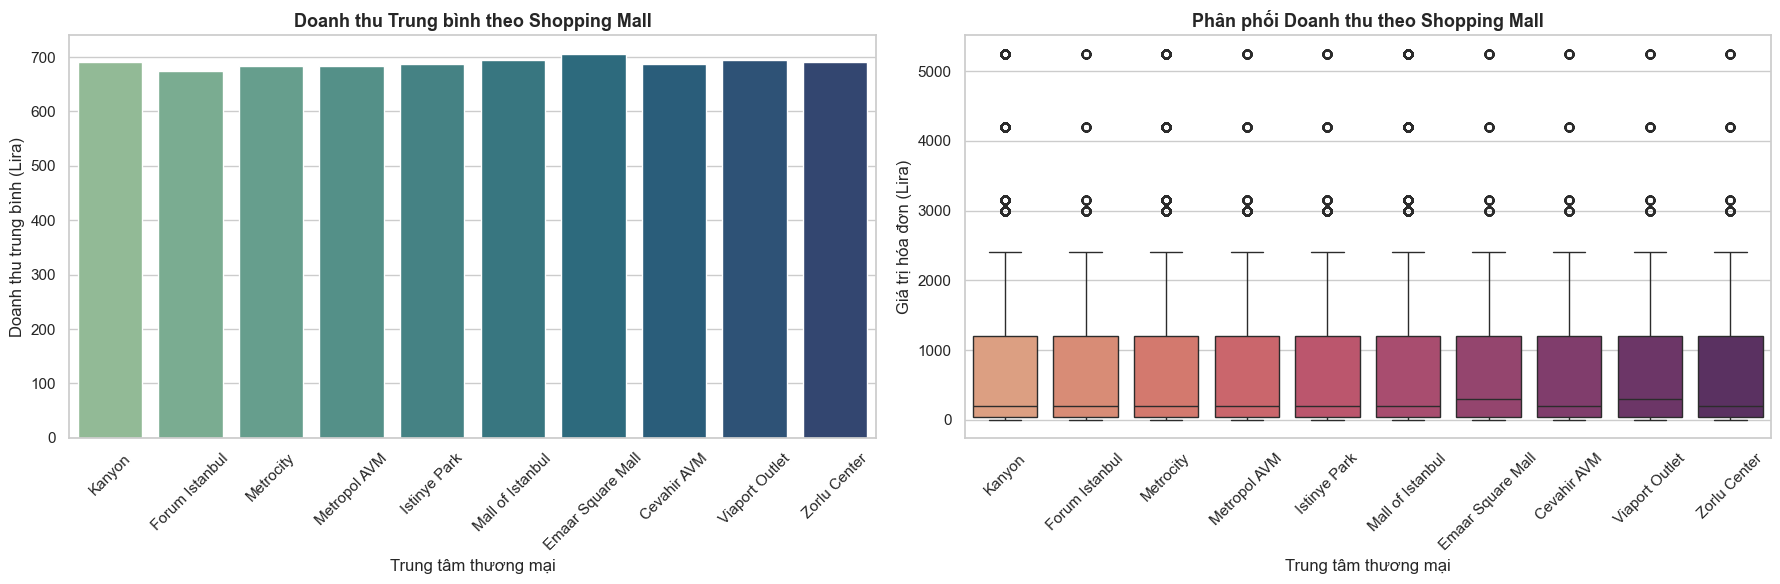

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Doanh thu trung bình theo Shopping Mall
sns.barplot(data=data, x='shopping_mall', y='price', ax=axes[0], palette='crest', errorbar=None)
axes[0].set_title('Doanh thu Trung bình theo Shopping Mall', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Trung tâm thương mại')
axes[0].set_ylabel('Doanh thu trung bình (Lira)')
axes[0].tick_params(axis='x', rotation=45)

# Phân phối doanh thu theo Shopping Mall
sns.boxplot(data=data, x='shopping_mall', y='price', ax=axes[1], palette='flare')
axes[1].set_title('Phân phối Doanh thu theo Shopping Mall', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Trung tâm thương mại')
axes[1].set_ylabel('Giá trị hóa đơn (Lira)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Dựa vào kết quả trên, ta có được các phân tích insight như sau:
- Tất cả các mall đều cao bằng nhau. Giá trị trung bình (Mean) dao động trong một biên độ cực kỳ hẹp, chỉ từ 674 Lira (Forum Istanbul) đến 704 Lira (Emaar Square Mall)

-> Theo logic bán lẻ thực tế đời sống, doanh thu trung bình ở một khu Outlet (Viaport Outlet - chuyên hàng giảm giá) phải khác biệt hoàn toàn so với một trung tâm thương mại xa xỉ (Emaar Square Mall). Tuy nhiên, dữ liệu này lại cho thấy khách hàng bước vào Mall nào cũng có mức chi tiêu y hệt nhau

- Mức Trung vị (Median) gần như bị đóng đinh ở con số 203.30 Lira. Đặc biệt, phía trên các hộp (từ mốc doanh thu 3000 đến hơn 5000) xuất hiện các dải chấm đen (Outliers) có mật độ và vị trí giống nhau y hệt ở cả 10 Mall

-> Dải Outlier này thực chất chính là các hóa đơn mua đồ Công nghệ (Technology có giá từ 3150 đến 5250 Lira) bị tách ra khỏi đám đông mua hàng bình dân. Việc các dải Outlier này phân bố đều đặn ở mọi Mall là bằng chứng thép: Tác giả Kaggle đã thiết kế dữ liệu bằng cách rải đều tỷ lệ mua đồ công nghệ đắt tiền cho tất cả các Shopping Mall một cách máy móc

Vì cột shopping_mall không tạo ra bất kỳ sự phân hóa nào về mặt Doanh thu (Boxplot và Outlier giống nhau 100%), độ tăng thông tin (Information Gain) của biến này gần như bằng 0 nên sẽ loại bỏ cột này trước khi đem train mô hình

In [28]:
display(data.groupby('gender')['price'].agg(['mean', 'median', 'std']).sort_values(by='mean', ascending=False).round(2))

,mean,median,std
gender,,,
Male,690.92,203.3,941.78
Female,688.14,203.3,940.79


C:\Users\minhchi\AppData\Local\Temp\ipykernel_4980\1763998608.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='gender', y='price', ax=axes[0], palette='Set2', errorbar=None)
C:\Users\minhchi\AppData\Local\Temp\ipykernel_4980\1763998608.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='gender', y='price', ax=axes[1], palette='Set3')


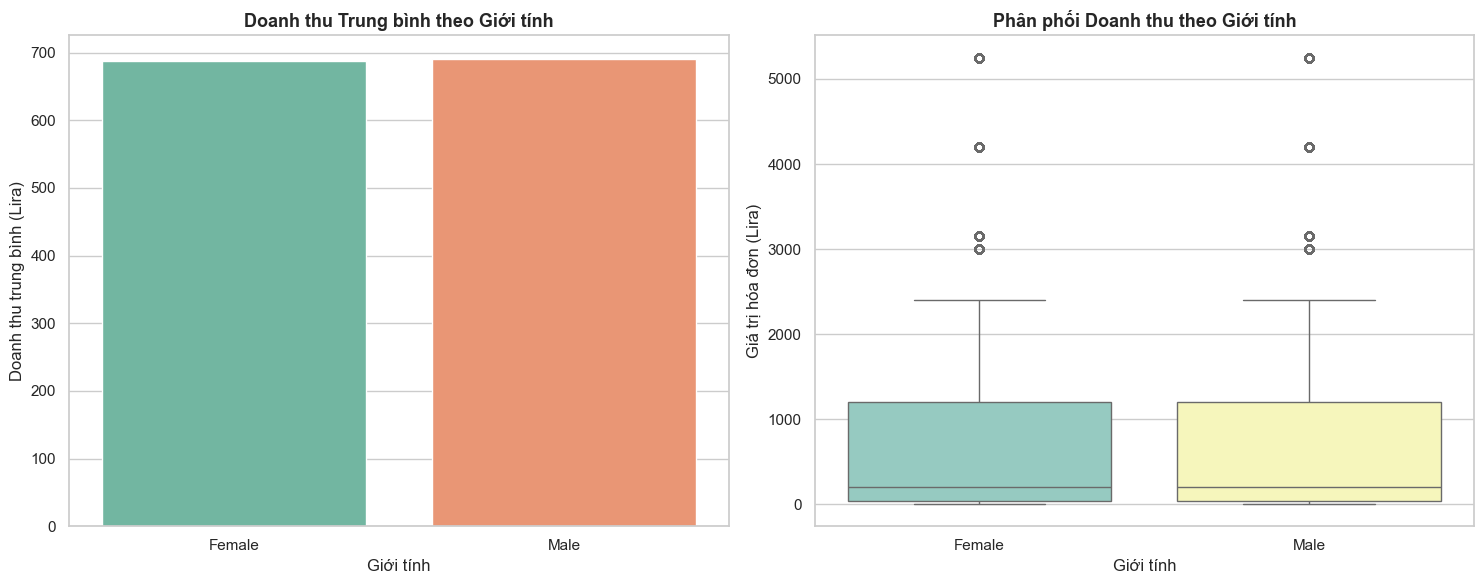

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Doanh thu trung bình theo Giới tính
sns.barplot(data=data, x='gender', y='price', ax=axes[0], palette='Set2', errorbar=None)
axes[0].set_title('Doanh thu Trung bình theo Giới tính', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Giới tính')
axes[0].set_ylabel('Doanh thu trung bình (Lira)')

# Phân phối doanh thu theo Giới tính
sns.boxplot(data=data, x='gender', y='price', ax=axes[1], palette='Set3')
axes[1].set_title('Phân phối Doanh thu theo Giới tính', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Giới tính')
axes[1].set_ylabel('Giá trị hóa đơn (Lira)')

plt.tight_layout()
plt.show()

Dựa vào kết quả trên, ta rút ra được phân tích sau:
- Doanh thu trung bình của Nam (Male - 690.92 Lira) và Nữ (Female - 688.14 Lira) gần như bằng nhau tuyệt đối
- Phân phối doanh thu theo nam và nữ giống hệt nhau như đúc. Mức trung vị (Median) đóng đinh ở 203.3 Lira. Các dải chấm đen (Outliers) đại diện cho việc mua đồ Công nghệ đắt tiền cũng phân bổ đều đặn và dày đặc y hệt nhau ở cả hai giới

-> Dữ liệu cho thấy Nam giới và Nữ giới có sức mua, độ chịu chi và tần suất mua các món đồ xa xỉ là ngang ngửa nhau. Không có giới tính nào "thống trị" doanh thu của trung tâm thương mại này. (Tuy nhiên, một lần nữa, sự hoàn hảo này mang đậm dấu ấn của Synthetic Data)

Tương tự như cột shopping_mall, gender không tạo ra bất kỳ sự phân hóa có ý nghĩa thống kê nào lên biến mục tiêu (Doanh thu). Thuật toán Học máy sẽ không học được nhiều quy luật từ việc phân biệt Nam/Nữ để dự đoán giá trị hóa đơn. Việc giữ lại hay Drop biến gender ở giai đoạn sau sẽ phụ thuộc vào việc chúng ta muốn tối ưu tốc độ huấn luyện hay muốn giữ lại để xem xét tác động tương hỗ (Interaction effects) với các biến khác (Ví dụ: Nam giới mua đồ Công nghệ nhiều hơn Nữ giới mua Mỹ phẩm)

In [31]:
display(data.groupby('payment_method')['price'].agg(['mean', 'median', 'std']).sort_values(by='mean', ascending=False).round(2))

,mean,median,std
payment_method,,,
Cash,690.82,203.3,942.60
Credit Card,688.54,203.3,943.07
Debit Card,687.03,203.3,934.79


C:\Users\minhchi\AppData\Local\Temp\ipykernel_4980\3810081058.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='payment_method', y='price', ax=axes[0], palette='pastel', errorbar=None)
C:\Users\minhchi\AppData\Local\Temp\ipykernel_4980\3810081058.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='payment_method', y='price', ax=axes[1], palette='Set2')


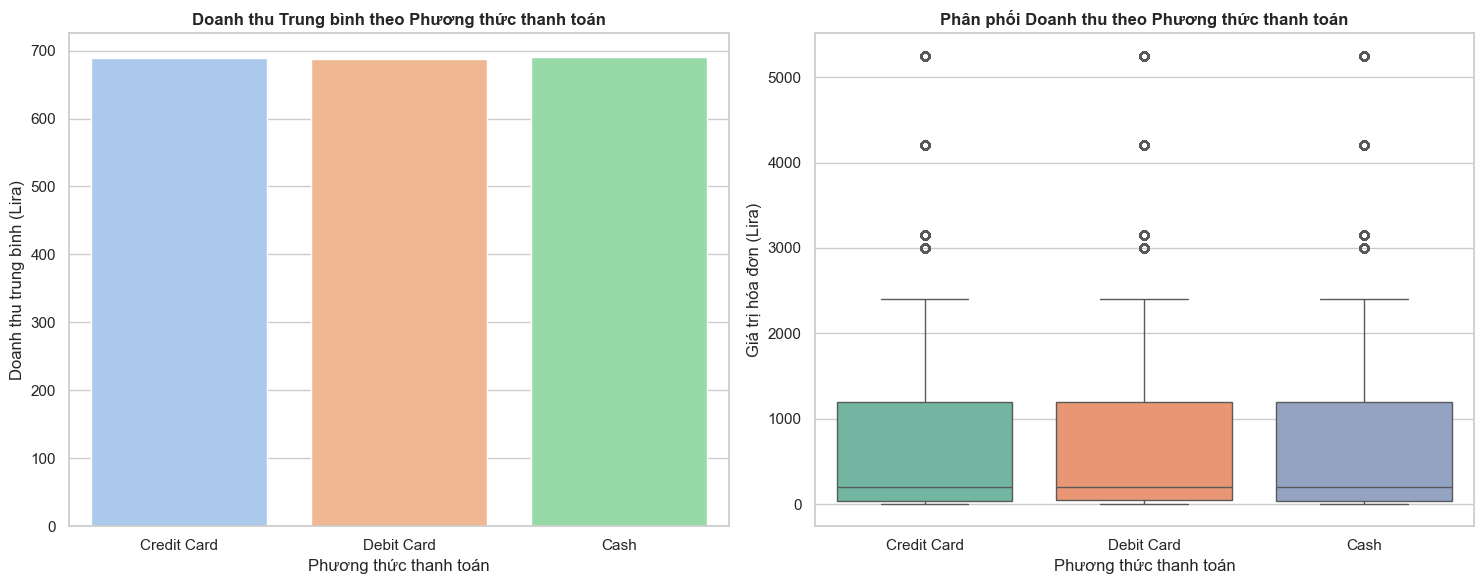

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Doanh thu trung bình theo Phương thức thanh toán
sns.barplot(data=data, x='payment_method', y='price', ax=axes[0], palette='pastel', errorbar=None)
axes[0].set_title('Doanh thu Trung bình theo Phương thức thanh toán', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Phương thức thanh toán')
axes[0].set_ylabel('Doanh thu trung bình (Lira)')

# Phân phối doanh thu theo Phương thức thanh toán
sns.boxplot(data=data, x='payment_method', y='price', ax=axes[1], palette='Set2')
axes[1].set_title('Phân phối Doanh thu theo Phương thức thanh toán', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Phương thức thanh toán')
axes[1].set_ylabel('Giá trị hóa đơn (Lira)')

plt.tight_layout()
plt.show()

Dựa vào kết quả trên, ta rút ra được phân tích sau:
- Khác biệt doanh thu trung bình giữa Tiền mặt (Cash - 690.82 Lira), Thẻ tín dụng (Credit Card - 688.54 Lira) và Thẻ ghi nợ (Debit Card - 687.03 Lira) là hoàn toàn không có ý nghĩa thống kê
- Mức trung vị đóng đinh ở 203.3 Lira, và dải Outliers (những khách mua đồ Công nghệ đắt tiền) xuất hiện đồng đều ở cả 3 phương thức thanh toán

-> Khách hàng mua ly nước 15 Lira hay mua dàn máy tính 5250 Lira đều có xác suất dùng Tiền mặt hoặc Thẻ ngang ngửa nhau. Tác giả bộ dữ liệu đã thiết lập tỷ lệ phương thức thanh toán hoàn toàn độc lập với giá trị đơn hàng

Cột biến payment_method chính thức gia nhập hội "những biến vô tri đối với Doanh thu" cùng với shopping_mall và gender. Với việc 3 biến phân loại này không cung cấp bất kỳ Thông tin dự báo nào cho biến mục tiêu price, ta sẽ loại bỏ chúng ở khâu Tiền xử lý, giúp mô hình (đặc biệt là Linear Regression) nhẹ gọn hơn và tránh được bẫy Overfitting

In [36]:
# Tạo bảng chéo tần suất (Crosstab) dạng số lượng
crosstab_count = pd.crosstab(data['shopping_mall'], data['gender'])

# Tạo bảng chéo tỷ lệ % theo từng Mall (để vẽ Stacked Bar Chart chuẩn xác)
crosstab_pct = pd.crosstab(data['shopping_mall'], data['gender'], normalize='index') * 100

In [37]:
display(crosstab_pct.round(2))

gender,Female,Male
shopping_mall,,
Cevahir AVM,58.91,41.09
Emaar Square Mall,59.07,40.93
Forum Istanbul,60.97,39.03
Istinye Park,60.06,39.94
Kanyon,60.06,39.94
Mall of Istanbul,59.68,40.32
Metrocity,59.56,40.44
Metropol AVM,60.47,39.53
Viaport Outlet,60.01,39.99


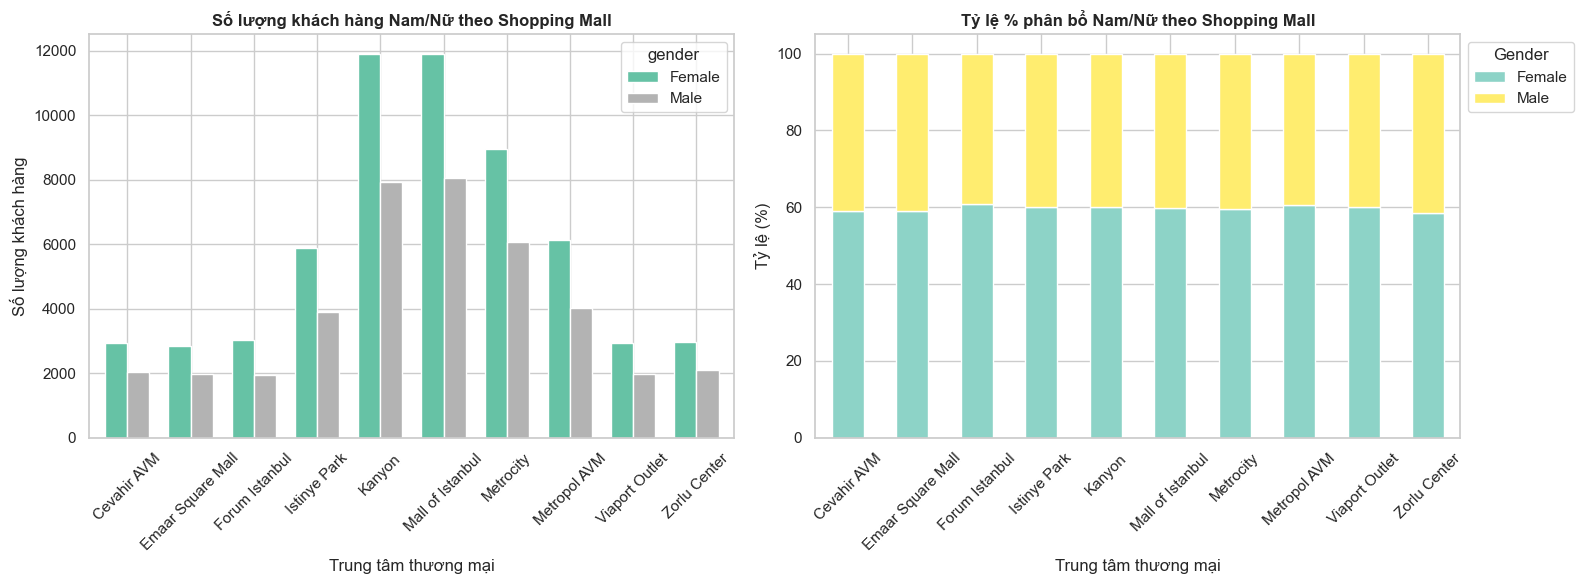

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grouped Bar Chart (Số lượng thực tế)
crosstab_count.plot(kind='bar', ax=axes[0], colormap='Set2', width=0.7)
axes[0].set_title('Số lượng khách hàng Nam/Nữ theo Shopping Mall', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Trung tâm thương mại')
axes[0].set_ylabel('Số lượng khách hàng')
axes[0].tick_params(axis='x', rotation=45)

# Stacked Bar Chart (Tỷ lệ %)
crosstab_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set3')
axes[1].set_title('Tỷ lệ % phân bổ Nam/Nữ theo Shopping Mall', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Trung tâm thương mại')
axes[1].set_ylabel('Tỷ lệ (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Gender', loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

Dựa vào bảng chéo tỷ lệ % và biểu đồ Stacked Bar Chart, ta nhận ra được rằng dù là một Outlet ngoại ô hay một Mall xa xỉ ở trung tâm, tỷ lệ giới tính của khách hàng luôn bị "đóng đinh" ở mức: ~60% Nữ (Female) và ~40% Nam (Male). Độ lệch giữa các Mall chỉ dao động vi phân ở mức 1-2%, một con số quá hoàn hảo để có thể tồn tại trong thực tế

-> Trong thực tế, các Mall có định vị thương hiệu và tệp khách hàng rất khác nhau. Tuy nhiên, tập dữ liệu này cho thấy không có bất kỳ rào cản địa lý hay định vị nào ảnh hưởng đến việc thu hút giới tính. Sự phân bổ đều tăm tắp này tiếp tục là bằng chứng cho thấy đây là Synthetic Data, được tạo ra bằng cách gán cố định xác suất Nữ=0.6 và Nam=0.4 cho mọi dòng dữ liệu

In [39]:
# Tạo bảng chéo tỷ lệ % (Nữ chiếm bao nhiêu %, Nam chiếm bao nhiêu % trong từng ngành hàng)
crosstab_cat_gender = pd.crosstab(data['category'], data['gender'], normalize='index') * 100

In [40]:
display(crosstab_cat_gender.round(2))

gender,Female,Male
category,,
Books,58.34,41.66
Clothing,59.88,40.12
Cosmetics,60.08,39.92
Food & Beverage,59.58,40.42
Shoes,59.47,40.53
Souvenir,60.35,39.65
Technology,59.67,40.33
Toys,60.33,39.67


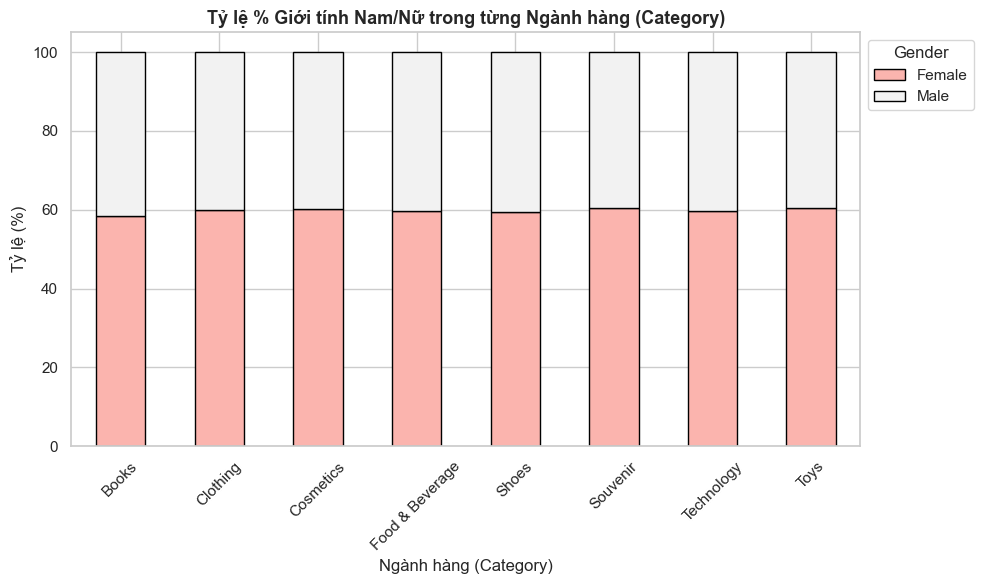

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))

# Stacked Bar Chart
crosstab_cat_gender.plot(kind='bar', stacked=True, ax=ax, colormap='Pastel1', edgecolor='black')
ax.set_title('Tỷ lệ % Giới tính Nam/Nữ trong từng Ngành hàng (Category)', fontsize=13, fontweight='bold')
ax.set_xlabel('Ngành hàng (Category)')
ax.set_ylabel('Tỷ lệ (%)')
ax.tick_params(axis='x', rotation=45)

ax.legend(title='Gender', loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

Dựa vào bảng chéo tỷ lệ % và biểu đồ Stacked Bar Chart, ta rút ra Insight Hành vi mua sắm:
- Bất kể là ngành hàng đặc thù như Mỹ phẩm (Cosmetics), Giày dép (Shoes) hay Công nghệ (Technology), tỷ lệ khách hàng luôn bị khóa chặt ở mốc ~60% Nữ và ~40% Nam

-> Trong thực tế ngành bán lẻ, sở thích chọn ngành hàng bị ảnh hưởng cực kỳ mạnh mẽ bởi giới tính. Việc Nam giới và Nữ giới có tỷ lệ mua sắm Mỹ phẩm và Đồ công nghệ giống hệt nhau là điều phi thực tế

In [45]:
# Tạo bảng chéo tỷ lệ % (Mỗi ngành hàng dùng các phương thức thanh toán với tỷ lệ bao nhiêu)
crosstab_cat_payment = pd.crosstab(data['category'], data['payment_method'], normalize='index') * 100

In [46]:
display(crosstab_cat_payment.round(2))

payment_method,Cash,Credit Card,Debit Card
category,,,
Books,45.53,34.05,20.42
Clothing,44.82,34.87,20.31
Cosmetics,44.21,35.34,20.45
Food & Beverage,44.58,35.53,19.89
Shoes,44.59,35.41,20.00
Souvenir,44.23,35.41,20.36
Technology,44.74,35.09,20.18
Toys,45.03,35.17,19.80


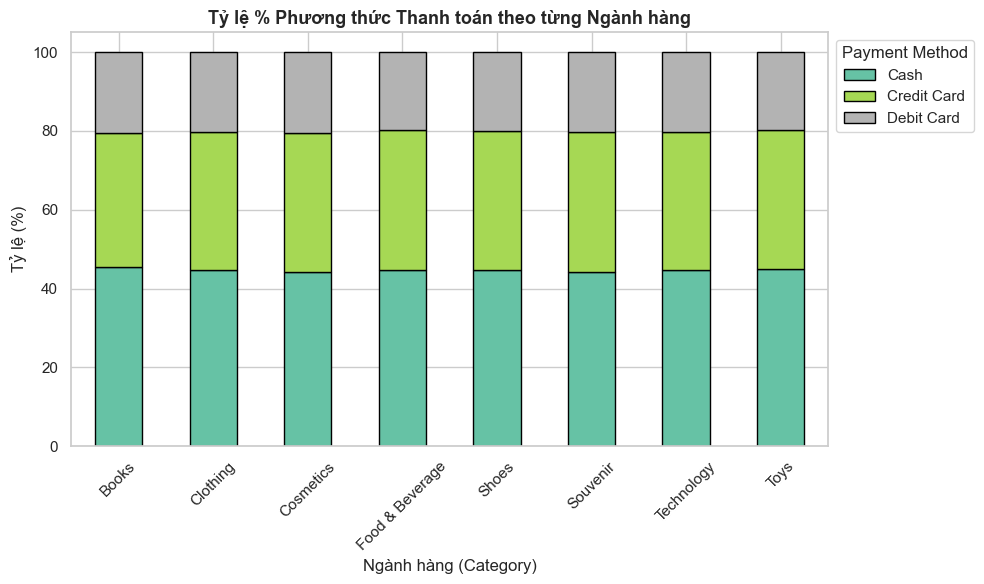

In [47]:
fig, ax = plt.subplots(figsize=(10, 6))

crosstab_cat_payment.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='black')
ax.set_title('Tỷ lệ % Phương thức Thanh toán theo từng Ngành hàng', fontsize=13, fontweight='bold')
ax.set_xlabel('Ngành hàng (Category)')
ax.set_ylabel('Tỷ lệ (%)')
ax.tick_params(axis='x', rotation=45)

ax.legend(title='Payment Method', loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

Dựa vào bảng chéo tỷ lệ % và biểu đồ Stacked Bar Chart, ta rút ra Insight Thanh toán:
- Bất chấp sự chênh lệch khổng lồ về giá trị đơn hàng giữa các ngành (Công nghệ có thể lên tới hàng ngàn Lira, trong khi Đồ ăn chỉ mười mấy Lira), cơ cấu thanh toán của khách hàng hoàn toàn không thay đổi. Nó luôn được khóa chặt ở tỷ lệ: ~45% Tiền mặt (Cash), ~35% Thẻ tín dụng (Credit Card) và ~20% Thẻ ghi nợ (Debit Card) cho MỌI ngành hàng

-> Dữ liệu này đi ngược lại hoàn toàn với logic tài chính hành vi thông thường. Việc một người mua gói kẹo hay mua dàn máy tính cao cấp đều tuân theo cùng một tỷ lệ quẹt thẻ chứng tỏ biến payment_method được sinh ngẫu nhiên độc lập. Đây là mảnh ghép cuối cùng khẳng định toàn bộ tập dữ liệu Kaggle này được tạo ra bằng một thuật toán gán xác suất tĩnh

In [48]:
df_time = data.copy()
df_time['invoice_date'] = pd.to_datetime(df_time['invoice_date'], format='%d/%m/%Y')
df_time['Month'] = df_time['invoice_date'].dt.month
df_time['DayOfWeek'] = df_time['invoice_date'].dt.day_name()

In [49]:
# Sắp xếp ngày trong tuần
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_time['DayOfWeek'] = pd.Categorical(df_time['DayOfWeek'], categories=days_order, ordered=True)

In [51]:
display(df_time.groupby('Month')['price'].sum().astype(int))

Month
1     7932626
2     7235297
3     6007346
4     5102478
5     5346926
6     5160345
7     5552023
8     5270542
9     5115214
10    5538258
11    4995141
12    5295165
Name: price, dtype: int64

In [52]:
display(df_time.groupby('Month')['price'].mean().round(2))

Month
1     683.38
2     690.26
3     688.13
4     681.51
5     694.68
6     680.69
7     704.84
8     690.31
9     695.66
10    713.33
11    660.47
12    689.47
Name: price, dtype: float64

C:\Users\minhchi\AppData\Local\Temp\ipykernel_4980\1677507485.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_time, x='Month', y='price', estimator=sum, ax=axes[0, 0], palette='viridis', errorbar=None)
C:\Users\minhchi\AppData\Local\Temp\ipykernel_4980\1677507485.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_time, x='Month', y='price', estimator='mean', ax=axes[0, 1], palette='viridis', errorbar=None)
C:\Users\minhchi\AppData\Local\Temp\ipykernel_4980\1677507485.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(

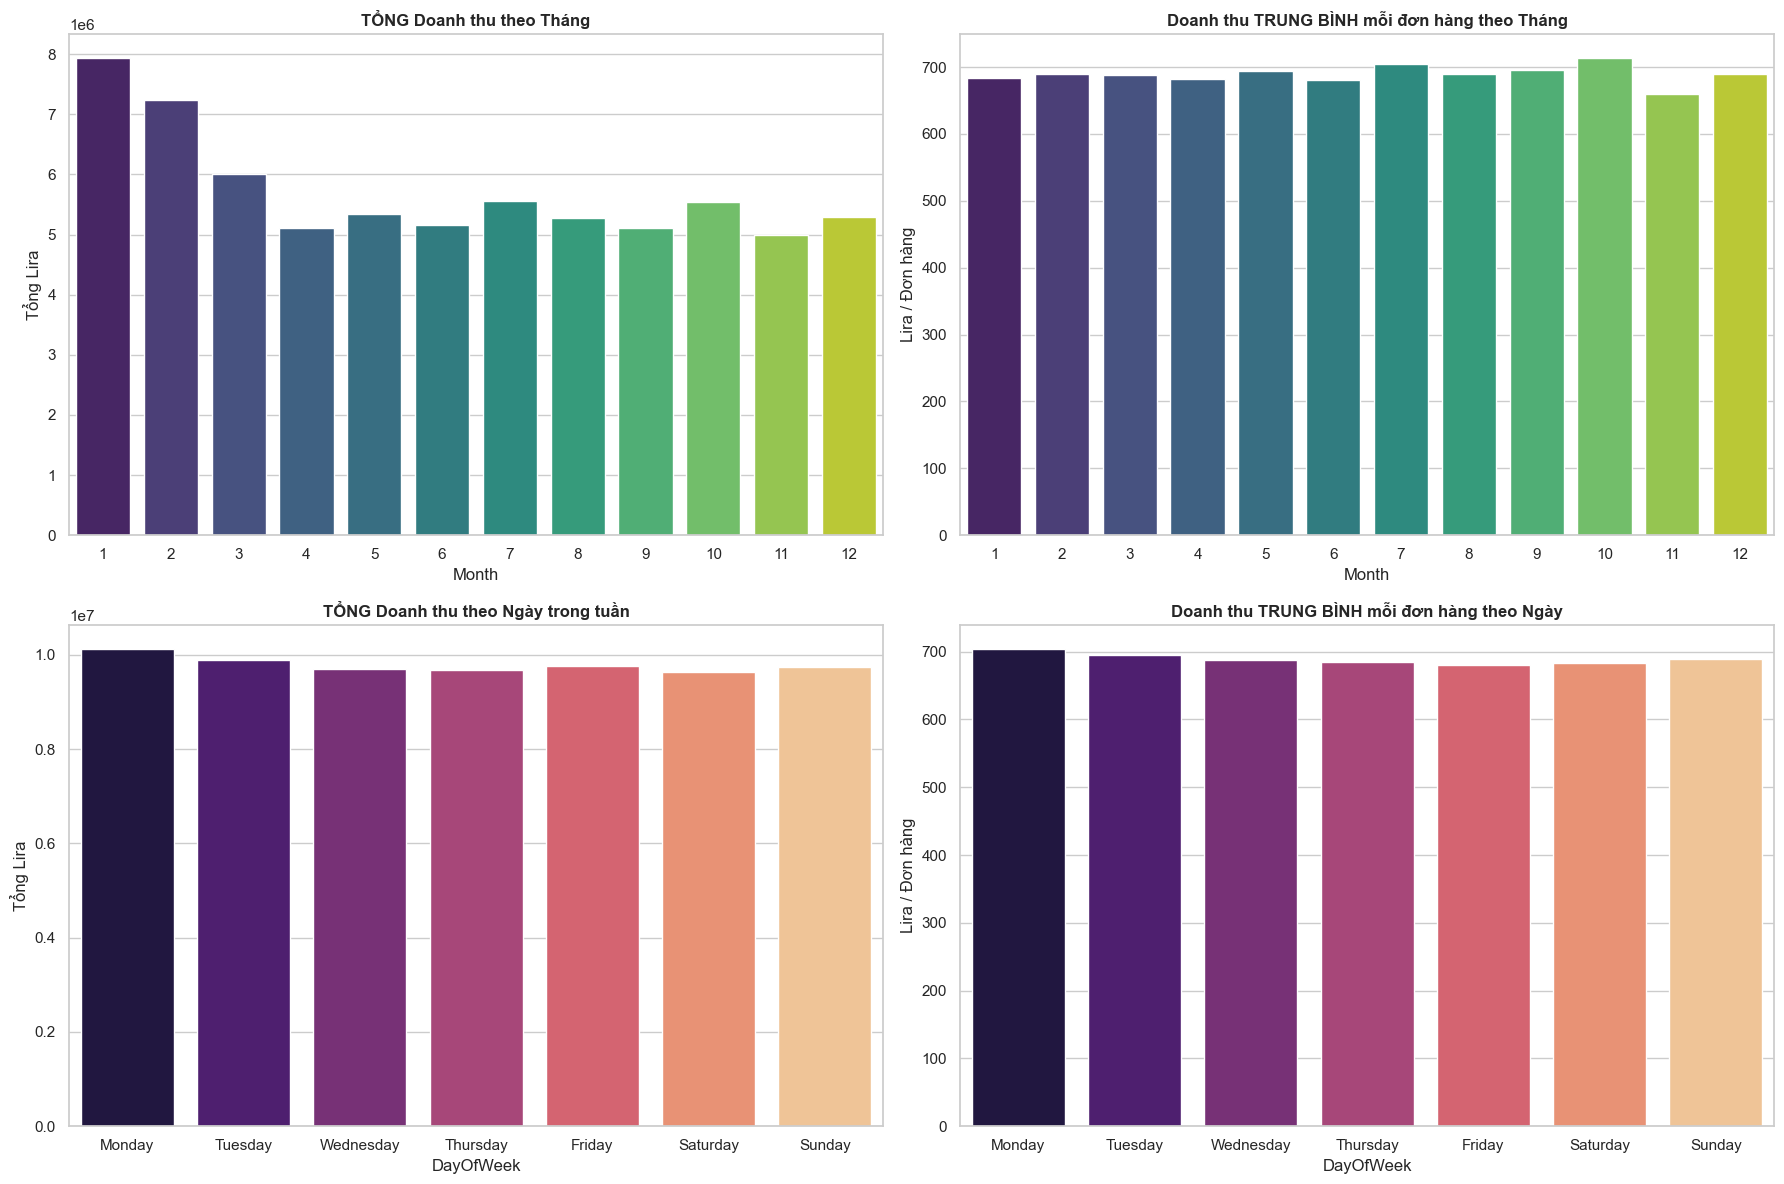

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# HÀNG 1: THEO THÁNG (MONTH)
# 1.1 Tổng doanh thu theo Tháng
sns.barplot(data=df_time, x='Month', y='price', estimator=sum, ax=axes[0, 0], palette='viridis', errorbar=None)
axes[0, 0].set_title('TỔNG Doanh thu theo Tháng', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Tổng Lira')

# 1.2 Doanh thu trung bình theo Tháng
sns.barplot(data=df_time, x='Month', y='price', estimator='mean', ax=axes[0, 1], palette='viridis', errorbar=None)
axes[0, 1].set_title('Doanh thu TRUNG BÌNH mỗi đơn hàng theo Tháng', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Lira / Đơn hàng')

# HÀNG 2: THEO NGÀY TRONG TUẦN (DAY OF WEEK)
# 2.1 Tổng doanh thu theo Ngày
sns.barplot(data=df_time, x='DayOfWeek', y='price', estimator=sum, ax=axes[1, 0], palette='magma', errorbar=None)
axes[1, 0].set_title('TỔNG Doanh thu theo Ngày trong tuần', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Tổng Lira')

# 2.2 Doanh thu trung bình theo Ngày
sns.barplot(data=df_time, x='DayOfWeek', y='price', estimator='mean', ax=axes[1, 1], palette='magma', errorbar=None)
axes[1, 1].set_title('Doanh thu TRUNG BÌNH mỗi đơn hàng theo Ngày', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Lira / Đơn hàng')

plt.tight_layout()
plt.show()

Dựa vào biểu đồ và số liệu thống kê Doanh thu theo Thời gian (Time Series), ta rút ra các Insight sau:
- Giống hệt với xu hướng lưu lượng đơn hàng ở phần Univariate, Tổng doanh thu vọt lên đỉnh điểm vào Tháng 1 (7.93 triệu Lira) và Tháng 2 (7.23 triệu Lira). Tuy nhiên, khi nhìn sang biểu đồ Doanh thu Trung bình, các cột lại cao bằng nhau tăm tắp, dao động nhẹ quanh mức 660 - 713 Lira/đơn cho mọi tháng

-> Sự gia tăng doanh thu trong 2 tháng đầu năm 100% đến từ việc tăng số lượng khách hàng/đơn hàng (Volume), chứ không phải do khách hàng mua những món đồ đắt đỏ hơn hay giỏ hàng lớn hơn (Giá trị trung bình đơn hàng - AOV không đổi)

- Cả Tổng doanh thu và Doanh thu trung bình theo 7 ngày trong tuần đều là những đường thẳng tắp

-> Trong thực tế bán lẻ, cuối tuần thường có xu hướng mua sắm các món đồ giá trị cao hơn hoặc đi theo nhóm đông người. Việc AOV đứng im ở mọi ngày, mọi tháng tiếp tục là minh chứng cho thấy tác giả đã "nhân bản" cùng một phân phối giá trị hóa đơn cho mọi mốc thời gian

Vậy cần tạo biến cờ kích hoạt bằng 1 cho Tháng 1 và Tháng 2 với dữ liệu thời gian giúp mô hình bắt được xu hướng tăng Volume, ngoài ra các đặc trưng như Ngày trong tuần (Day of Week) hay thậm chí là Tháng (sau khi đã trích xuất Campaign) không mang lại bất kỳ sự phân hóa nào về mặt Doanh thu trung bình. Đề xuất Drop các biến này để tránh làm mô hình Hồi quy bị loãng trọng số

#### **Outlier Detection**
- Tập trung phân tích phân phối đuôi dài của biến price (Tổng hóa đơn - đại diện cho Doanh thu)
- Sử dụng phương pháp IQR để đếm số lượng hóa đơn có giá trị "bất thường" (mua quá nhiều hoặc giá quá cao)

In [53]:
def detect_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Lọc ra các dòng là outlier
    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
    
    return len(outliers), lower_bound, upper_bound

In [54]:
num_outliers, lower, upper = detect_outliers_iqr(data, 'price')
total_rows = len(data)
outlier_percent = (num_outliers / total_rows) * 100

In [56]:
print(f"-> Biến mục tiêu: REVENUE (Doanh thu / Price)")
print(f"   - Ngưỡng dưới an toàn (Lower Bound): {lower:.2f} Lira")
print(f"   - Ngưỡng trên an toàn (Upper Bound): {upper:.2f} Lira")
print(f"   - Số lượng hóa đơn Ngoại lai (Outliers): {num_outliers:,} / {total_rows:,} hóa đơn")
print(f"   - Tỷ lệ Ngoại lai: {outlier_percent:.2f}%")

-> Biến mục tiêu: REVENUE (Doanh thu / Price)
   - Ngưỡng dưới an toàn (Lower Bound): -1686.85 Lira
   - Ngưỡng trên an toàn (Upper Bound): 2932.62 Lira
   - Số lượng hóa đơn Ngoại lai (Outliers): 5,024 / 99,457 hóa đơn
   - Tỷ lệ Ngoại lai: 5.05%


- Về mặt thống kê, có 5,024 hóa đơn (chiếm 5.05%) có doanh thu vượt ngưỡng an toàn trên (2932.62 Lira) bị thuật toán gắn cờ là điểm dị biệt. Tuy nhiên , thông qua bước phân tích Bivariate (Boxplot Doanh thu theo Ngành hàng) thì đây hoàn toàn không phải là dữ liệu rác hay lỗi nhập liệu. Những hóa đơn > 3000 Lira này chính là bản chất định giá tự nhiên của ngành hàng Công nghệ (Technology) khi khách hàng mua với số lượng từ 3, 4 đến 5 món

### **4. Data Preprocessing**
Các bước thực hiện:
- Data Cleaning:
    - Xử lý Duplicate: Quét và xóa bỏ các dòng giao dịch trùng lặp hoàn toàn.
    - Xử lý Inconsistent Type: Ép kiểu cột invoice_date về định dạng Datetime, cột price về Float.
    - Xử lý Invalid/Noisy Data: Chuẩn hóa lỗi gõ chữ (Ví dụ: Đưa "Male", "male", "M" về chuẩn chung là "Male").
    - Xử lý Domain Constraints: Xóa các dòng phi logic (VD: age < 10, price < 0).
    - Xử lý Missing Values: Xóa (Drop) các dòng chứa giá trị NaN nếu tỷ lệ rất thấp
    - Xử lý Outlier: Dùng phương pháp IQR để phát hiện và Cắt tỉa/Xóa bỏ các hóa đơn có giá trị dị biệt, giúp làm sạch dữ liệu trước khi đưa vào mô hình

In [57]:
data.head(10)

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon
5,I227836,C657758,Female,28,Clothing,5,1500.40,Credit Card,24/05/2022,Forum Istanbul
6,I121056,C151197,Female,49,Cosmetics,1,40.66,Cash,13/03/2022,Istinye Park
7,I293112,C176086,Female,32,Clothing,2,600.16,Credit Card,13/01/2021,Mall of Istanbul
8,I293455,C159642,Male,69,Clothing,3,900.24,Credit Card,4/11/2021,Metrocity
9,I326945,C283361,Female,60,Clothing,2,600.16,Credit Card,22/08/2021,Kanyon


In [61]:
# Xử lý Duplicate
print(data.duplicated().sum())
data = data.drop_duplicates()

0


In [62]:
# Xử lý Inconsistent Type
# Dữ liệu ngày tháng trong dataset này thường ở dạng dd/mm/yyyy
data['invoice_date'] = pd.to_datetime(data['invoice_date'], format='%d/%m/%Y')

In [63]:
# Xử lý Invalid/Noisy Data
data['gender'] = data['gender'].str.title().str.strip()
data['category'] = data['category'].str.title().str.strip()
data['shopping_mall'] = data['shopping_mall'].astype(str).str.title()
data['payment_method'] = data['payment_method'].astype(str).str.title()

In [65]:
# Xử lý Domain Constraints
# Lọc bỏ các dòng tuổi < 10 hoặc doanh thu <= 0 (phi logic)
logic_mask = (data['age'] >= 10) & (data['price'] > 0)
invalid_count = len(data) - logic_mask.sum()
data = data[logic_mask]

In [66]:
# Xử lý Missing Values
print(data.isnull().any(axis=1).sum())
data = data.dropna()

0


In [67]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_no      99457 non-null  object        
 1   customer_id     99457 non-null  object        
 2   gender          99457 non-null  object        
 3   age             99457 non-null  int64         
 4   category        99457 non-null  object        
 5   quantity        99457 non-null  int64         
 6   price           99457 non-null  float64       
 7   payment_method  99457 non-null  object        
 8   invoice_date    99457 non-null  datetime64[ns]
 9   shopping_mall   99457 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 7.6+ MB


In [68]:
data.head(5)

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol Avm
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon


In [71]:
data.to_csv('./data/preprocessed-data/preprocessed_customer_shopping_data.csv',index=False)